# Step 5 — Polynomial Modeling and Image Reconstruction

This notebook covers the final step of the PLred pipeline.

**Input:** `step4_couplingmap.fits` (output of Step 4 — spectral extraction)  
**Outputs:** `polymodel.fits`, reconstructed images

---

### Workflow

1. **[Load coupling map](#sec1)** — read the `step4_couplingmap.fits`
2. **[Inspect wavelength range](#sec2)** — pick `wav_fitrange` and `wav_reconrange`
3. **[Fit polynomial model](#sec3)** — smooth spatial + spectral polynomial interpolation
4. **[Diagnostics](#sec4)** — spatial maps, spectra, and animation
5. **[Astrometry](#sec5)** — chi² centroid fitting across wavelengths
6. **[Image reconstruction](#sec6)** — MCMC simulated-annealing image reconstruction

## Setup

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

TUTORIAL_DIR = os.path.dirname(os.path.abspath('__file__'))
sys.path.insert(0, os.path.join(TUTORIAL_DIR, '..', '..'))

import PLred.mapmodel as mm
import PLred.recon_utils as ru
from PLred.imgrecon import locs2image

# ── Paths ───────────────────────────────────────────────────────────────────
COUPLINGMAP = os.path.join(TUTORIAL_DIR, 'test_20250211_betcmi', 'step4_couplingmap_optimal_extraction.fits')
OUTPUT_DIR  = os.path.join(TUTORIAL_DIR, 'test_20250211_betcmi')
os.makedirs(OUTPUT_DIR, exist_ok=True)

POLYMODEL   = os.path.join(OUTPUT_DIR, 'polymodel')   # .fits is added automatically

print(f'Coupling map : {COUPLINGMAP}')
print(f'Polymodel    : {POLYMODEL}.fits')

Coupling map : /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/test_20250211_betcmi/step4_couplingmap_optimal_extraction.fits
Polymodel    : /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/test_20250211_betcmi/polymodel.fits


<a id='sec1'></a>
## 1. Load coupling map

In [23]:
# min_nframes: discard grid bins with fewer than this many frames.
# Increase to 5–10 for observations with many frames per bin.
mapmodel = mm.CouplingMapModel(mapdata=COUPLINGMAP, min_nframes=5)

nwav = mapmodel.normdata.shape[3]
print(f'Grid     : {mapmodel.map_n} × {mapmodel.map_n}')
print(f'Fibers   : {mapmodel.nfib}')
print(f'Channels : {nwav}')
print(f'FOV      : {mapmodel.pos_mas[0]:.1f} … {mapmodel.pos_mas[-1]:.1f} mas')

loading mapdata
masking data with less than 5 frames
Grid     : 15 × 15
Fibers   : 38
Channels : 26
FOV      : -22.7 … 22.7 mas


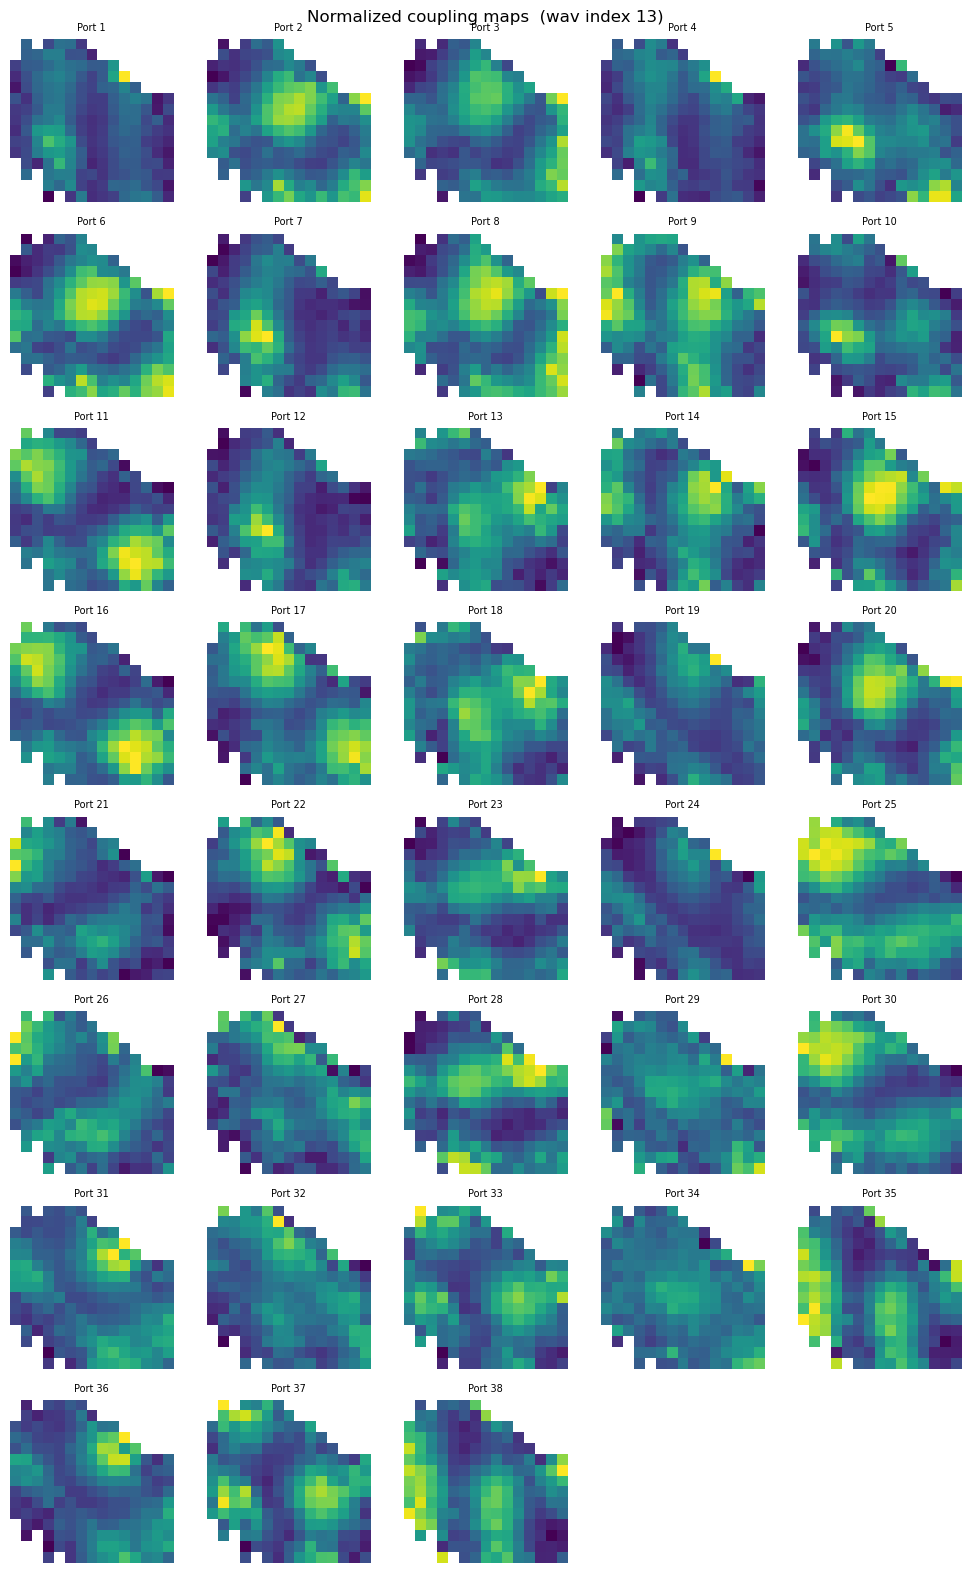

In [3]:
# Quick-look: normalized coupling maps at the middle wavelength
mid_wav = nwav // 2

fig, axs = plt.subplots(ncols=5, nrows=8, figsize=(10, 16), sharex=True, sharey=True)
axs = axs.flatten()
for i in range(38):
    axs[i].imshow(mapmodel.normdata[:, :, i, mid_wav], origin='lower')
    axs[i].set_title(f'Port {i+1}', fontsize=7)
    axs[i].axis('off')
for ax in axs[38:]:
    ax.axis('off')
fig.suptitle(f'Normalized coupling maps  (wav index {mid_wav})')
plt.tight_layout()
plt.show()

<a id='sec2'></a>
## 2. Inspect wavelength range

First, use `plot_fiber_sum` to survey the data — summing over all fibers collapses
per-fiber noise while the science signal (which appears coherently across fibers)
stands out clearly.  This makes it easy to identify which wavelength indices contain
the target before zooming in with `inspect_wav_range`.

Then use `inspect_wav_range` on a single (ix, iy, fiber) position to finalize
`fitmin`/`fitmax`.  The polynomial model should fit the *instrumental* response, so
the science signal window (`fitmin:fitmax`) is **excluded** from the fit.

### 2a. Survey all grid positions (fiber-summed)

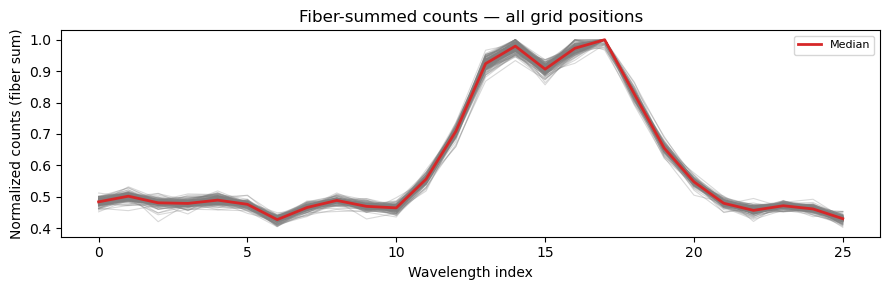

In [24]:
# Overlay fiber-summed spectra from all grid positions (gray) + median (red).
# Look for a bump or dip that appears consistently — that is the science signal.
fig = ru.plot_fiber_sum(mapmodel)
plt.show()

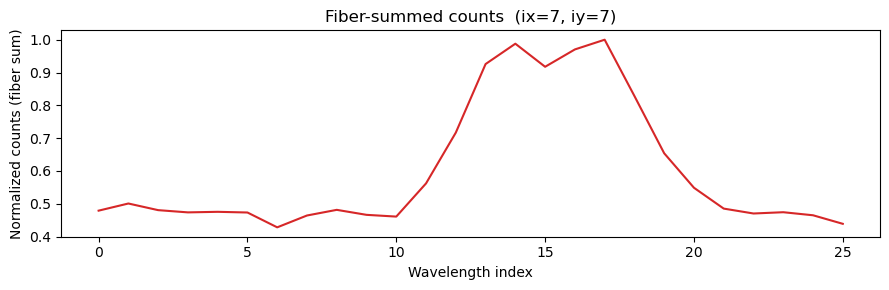

In [25]:
# Zoom in on one grid position to confirm.
# Replace ix, iy with the bin where you expect the target to be brightest.
fig = ru.plot_fiber_sum(mapmodel, ix=7, iy=7)
plt.show()

fit range    : 0–25  (excluding 10–19)
recon range  : 0–25


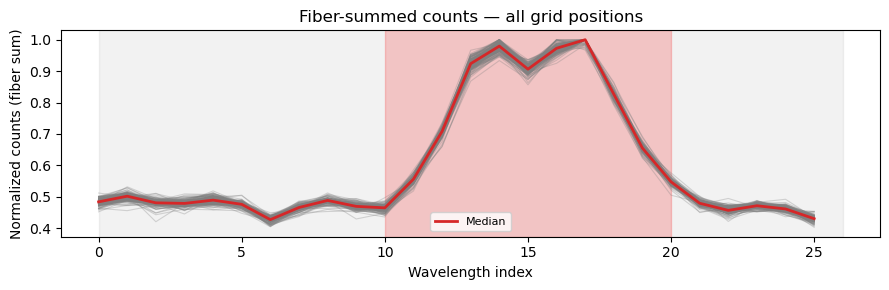

In [26]:
# ── Set wavelength ranges here ──────────────────────────────────────────────
wmin   = 0
wmax   = nwav       # inclusive end of the reconstruction range
fitmin = 10         # first wavelength to EXCLUDE (signal starts here)
fitmax = 20         # first wavelength to include again after the signal window

fig = ru.plot_fiber_sum(mapmodel)

wav_fitrange   = np.r_[wmin:fitmin, fitmax:wmax]   # wavelengths used for fitting
wav_reconrange = np.r_[wmin:wmax]                  # wavelengths to reconstruct

print(f'fit range    : {wav_fitrange[0]}–{wav_fitrange[-1]}  '
      f'(excluding {fitmin}–{fitmax-1})')
print(f'recon range  : {wav_reconrange[0]}–{wav_reconrange[-1]}')


plt.axvspan(fitmin, fitmax, color='red', alpha=0.2)
plt.axvspan(wmin, wmax, color='gray',alpha=0.1)

plt.show()

<a id='sec3'></a>
## 3. Fit polynomial model

The model is a 2-step polynomial:

1. At each wavelength in `wav_fitrange`, fit a **2-D spatial polynomial** to the
   coupling map across the (ix, iy) grid.
2. For each polynomial coefficient, fit a **1-D spectral polynomial** across
   wavelength, then evaluate at all wavelengths in `wav_reconrange` (including
   the signal window).

> **Tip** — if the spatial residuals show large-scale structure, increase
> `poly_deg_spatial`.  If the spectral coefficient curves are bumpy, increase
> `poly_deg_spectral`.  Start low (5–7) and increase as needed.

In [27]:
all_map_inputs, all_modeled_recons, all_modeled_coeffs, model_chi2 = ru.run_polymodel(
    mapmodel,
    wav_fitrange      = wav_fitrange,
    wav_reconrange    = wav_reconrange,
    output_name       = POLYMODEL,
    poly_deg_spatial  = 7,
    poly_deg_spectral = 5,
)
print(f'Model saved to {POLYMODEL}.fits')

  0%|          | 0/38 [00:00<?, ?it/s]

100%|██████████| 38/38 [00:02<00:00, 14.53it/s]


/Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/test_20250211_betcmi/polymodel.fits saved
Model saved to /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/test_20250211_betcmi/polymodel.fits


<a id='sec4'></a>
## 4. Diagnostics

Check that the polynomial model captures the smooth instrumental response and
does **not** fit the science signal (residuals inside `fitmin:fitmax` should
show structure, not noise).

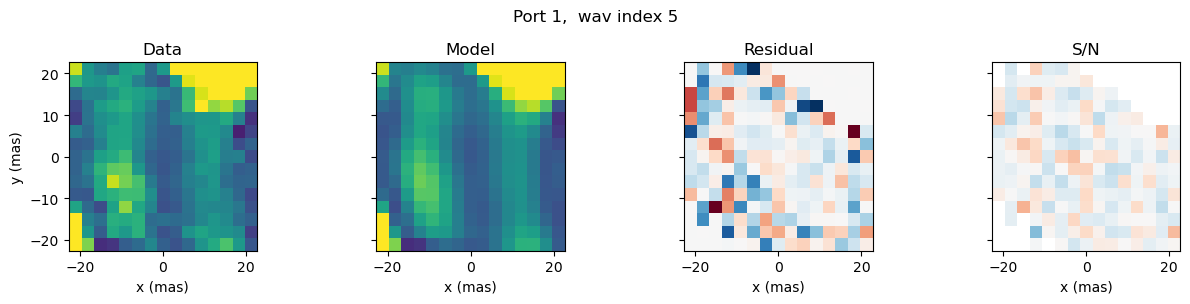

In [13]:
# 4-panel spatial map at one wavelength for one fiber
# specind: 0-based index into wav_reconrange
specind = 5
fig = ru.plot_polymodel_map(mapmodel, specind=specind, fibind=0)
plt.show()

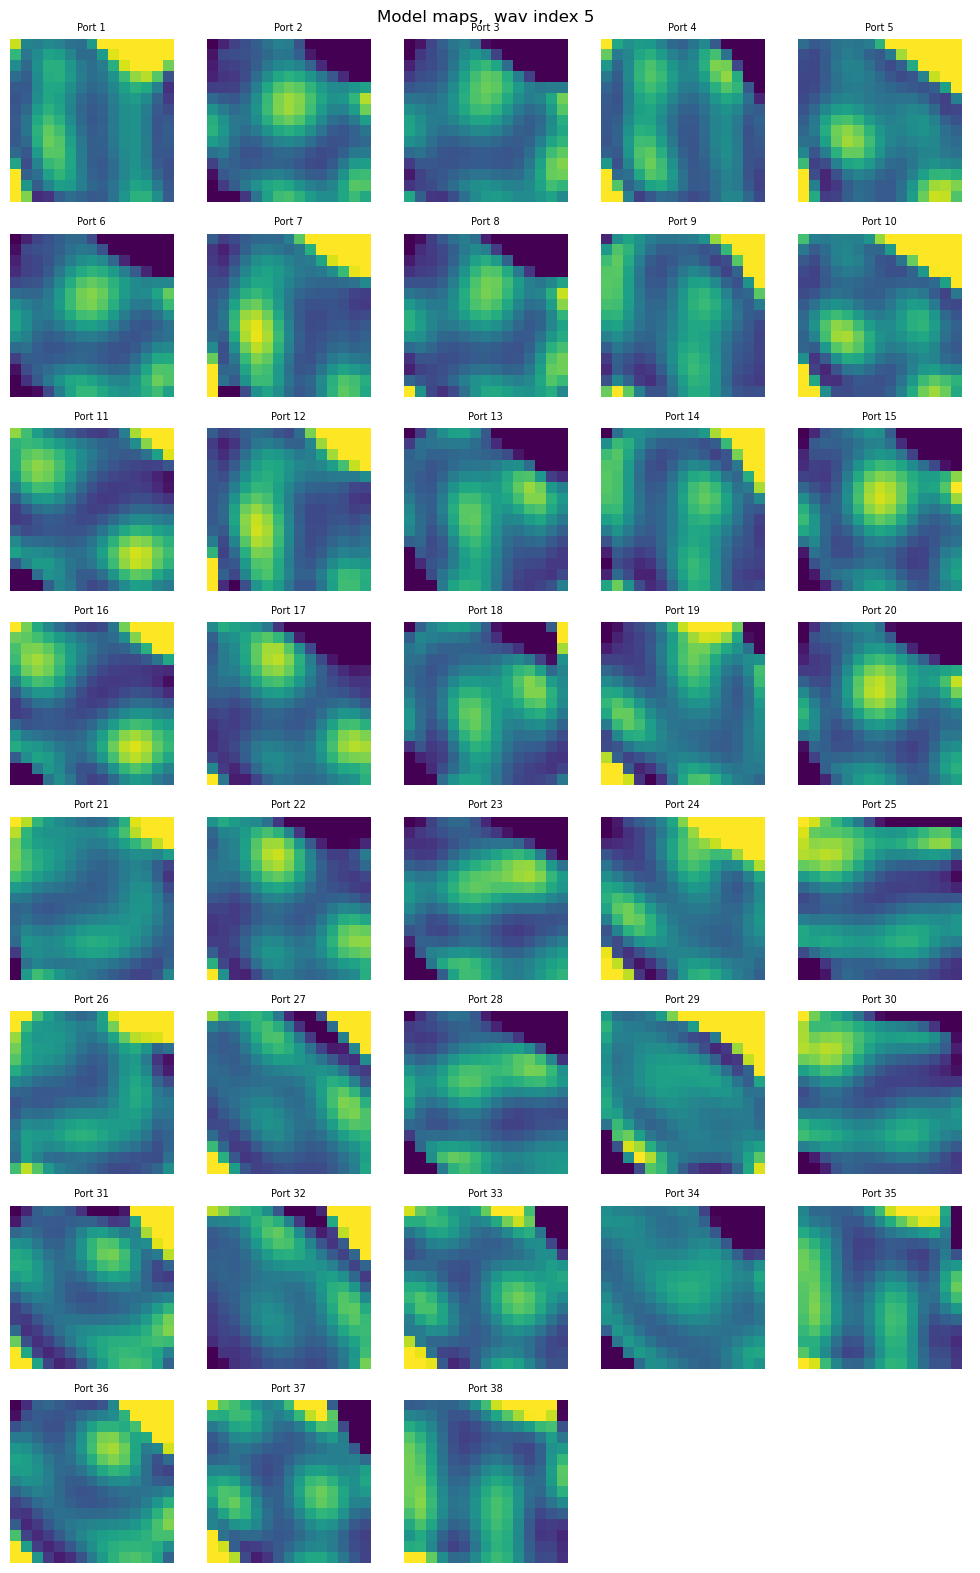

In [14]:
# All-fiber model map grid at one wavelength
fig = ru.plot_polymodel_map(mapmodel, specind=specind)
plt.show()

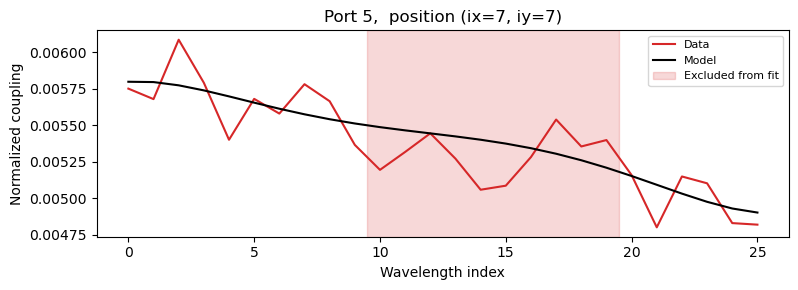

In [19]:
# Spectrum at one sky position: data vs. model
# The red shading shows the wavelengths excluded from the polynomial fit.
fig = ru.plot_polymodel_spectrum(mapmodel, ix=7, iy=7, fibind=4)
plt.show()

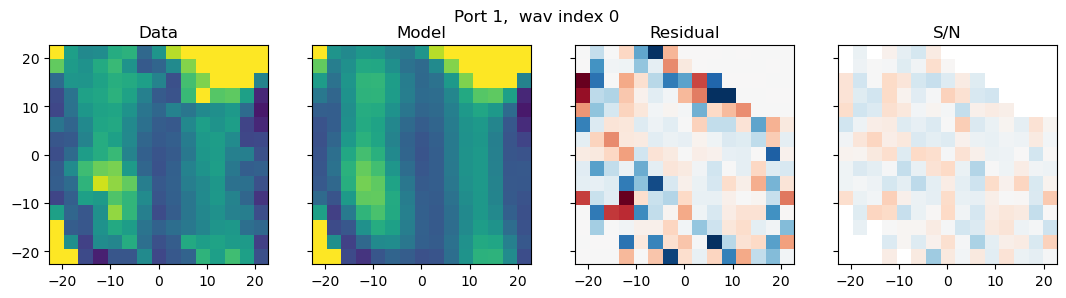

In [20]:
# Animation: data | model | residual | S/N across wavelengths
from IPython.display import HTML

ani = ru.animate_polymodel(mapmodel, fibind=0)
HTML(ani.to_jshtml())

---

Reload the saved polynomial model for astrometry and image reconstruction.
This makes `compute_vec` (the shifted-model evaluator) available.

In [29]:
fit_mm = mm.CouplingMapModel(model=POLYMODEL + '.fits')
print(f'Model loaded: wav_reconrange [{fit_mm.wav_reconrange[0]}–{fit_mm.wav_reconrange[-1]}]')

loading model
Model loaded: wav_reconrange [0–25]


<a id='sec5'></a>
## 5. Astrometry — centroid track across wavelengths

`run_astrometry` minimizes the reduced chi² over (x, y) centroid shifts for
each wavelength by comparing the polynomial model (evaluated at a shifted
sky position) against the observed coupling map.

A wavelength-dependent centroid track reveals atmospheric dispersion or, at
the science wavelength, the position and brightness of the target.

wav   0 (specind  0): x=+0.003 mas,  y=+0.004 mas,  chi2=1.652
wav   1 (specind  1): x=-0.013 mas,  y=+0.017 mas,  chi2=1.834
wav   2 (specind  2): x=-0.002 mas,  y=-0.010 mas,  chi2=1.940
wav   3 (specind  3): x=+0.023 mas,  y=+0.005 mas,  chi2=2.003
wav   4 (specind  4): x=+0.020 mas,  y=-0.017 mas,  chi2=2.209
wav   5 (specind  5): x=-0.026 mas,  y=+0.014 mas,  chi2=2.132
wav   6 (specind  6): x=+0.010 mas,  y=+0.062 mas,  chi2=2.147
wav   7 (specind  7): x=-0.054 mas,  y=-0.046 mas,  chi2=2.131
wav   8 (specind  8): x=-0.035 mas,  y=-0.071 mas,  chi2=2.288
wav   9 (specind  9): x=+0.020 mas,  y=+0.058 mas,  chi2=1.917
wav  10 (specind 10): x=-0.030 mas,  y=+0.220 mas,  chi2=2.634
wav  11 (specind 11): x=+0.004 mas,  y=+0.164 mas,  chi2=3.197
wav  12 (specind 12): x=+0.034 mas,  y=+0.368 mas,  chi2=3.543
wav  13 (specind 13): x=-0.005 mas,  y=+0.724 mas,  chi2=4.726
wav  14 (specind 14): x=+0.139 mas,  y=+0.820 mas,  chi2=4.874
wav  15 (specind 15): x=+0.271 mas,  y=+0.317 mas,  chi

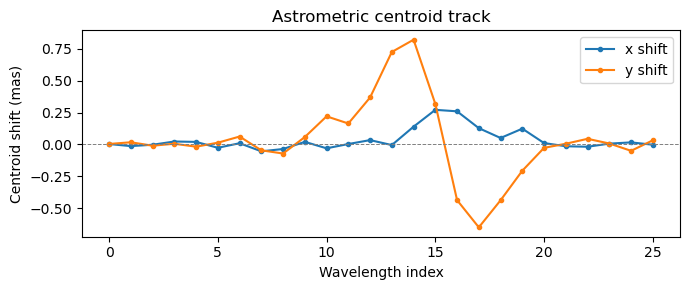

In [30]:
# Fit centroid at every wavelength in the recon range
astro_results = ru.run_astrometry(
    fit_mm,
    wav_indices = np.arange(len(wav_reconrange)),
    n_trim      = 1,
)

In [31]:
# Centroid shifts at signal wavelengths
signal_inds = np.arange(fitmin - wmin, fitmax - wmin)   # specind range for signal window
signal_results = [astro_results[i] for i in signal_inds]

for r in signal_results:
    print(f"wav {r['wav']:3d}: x = {r['x']:+.3f} mas,  y = {r['y']:+.3f} mas")

wav  10: x = -0.030 mas,  y = +0.220 mas
wav  11: x = +0.004 mas,  y = +0.164 mas
wav  12: x = +0.034 mas,  y = +0.368 mas
wav  13: x = -0.005 mas,  y = +0.724 mas
wav  14: x = +0.139 mas,  y = +0.820 mas
wav  15: x = +0.271 mas,  y = +0.317 mas
wav  16: x = +0.259 mas,  y = -0.436 mas
wav  17: x = +0.128 mas,  y = -0.648 mas
wav  18: x = +0.051 mas,  y = -0.437 mas
wav  19: x = +0.124 mas,  y = -0.205 mas


<a id='sec6'></a>
## 6. Image reconstruction

MCMC simulated-annealing image reconstruction: the image is parameterized as
a set of `n_elements` discrete flux elements, and the chain moves them to
minimize chi².

**Key hyperparameters:**

| Parameter | Role | Typical range |
|-----------|------|---------------|
| `image_fov` | Image field of view (mas) | 10–30 |
| `image_ngrid` | Pixels per side | 11–25 |
| `n_elements` | Flux elements; more → finer resolution but slower | 30–200 |
| `ini_temp` | Initial annealing temperature | 1e2–1e4 |
| `tau` | Cooling timescale | 1e4–1e6 |
| `target_chi2` | Convergence criterion (~1 for a good fit) | 1.0 |
| `niter` | Total iterations | 500–5000 |

loading model


225it [00:04, 45.98it/s]


all the fiber indices are used. saving the matrix to mat_full
preparing data for specind 10


  0%|          | 0/800 [00:00<?, ?it/s]

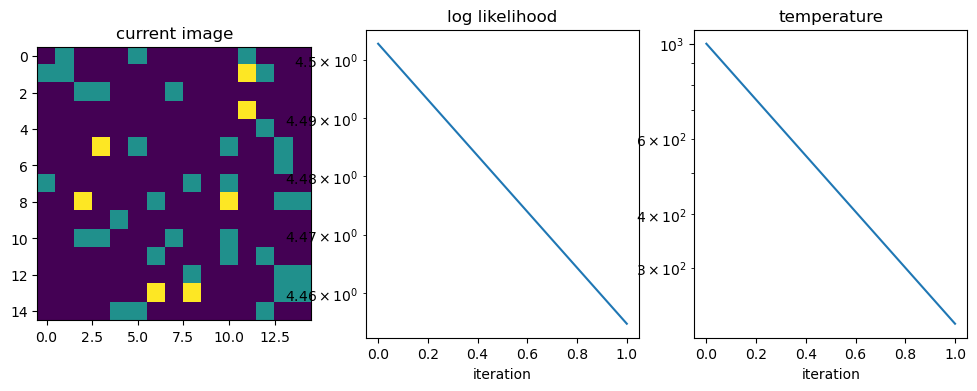

 61%|██████    | 489/800 [00:04<00:01, 163.69it/s]

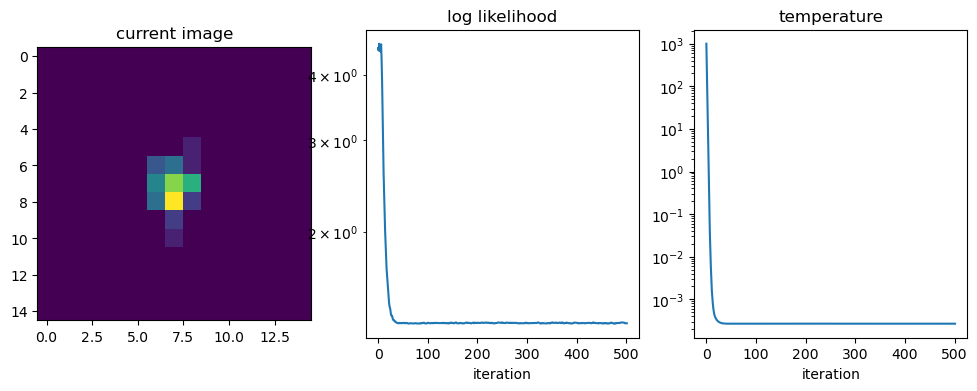

100%|██████████| 800/800 [00:07<00:00, 114.16it/s]


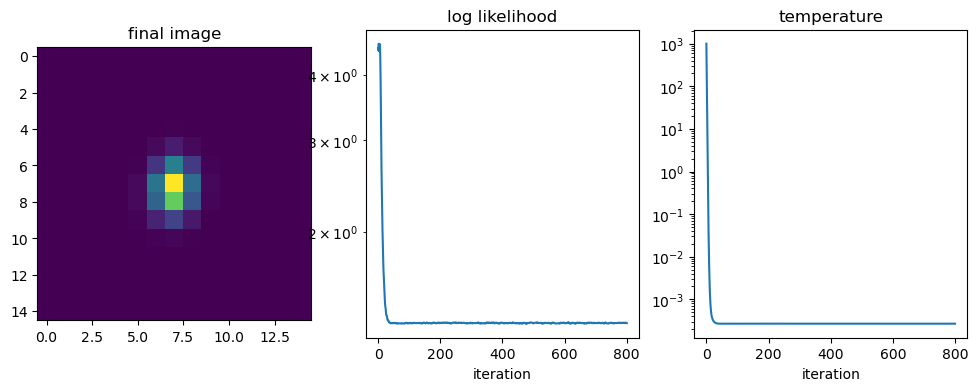

Done
Final chi2 2.674161337549196


In [32]:
# Reconstruct at one wavelength inside the signal window
wavind = fitmin - wmin    # 0-based specind

IMAGE_FOV   = 12    # mas
IMAGE_NGRID = 15

rc, fitter = ru.run_reconstruction(
    fit_mm,
    wavind       = wavind,
    image_fov    = IMAGE_FOV,
    image_ngrid  = IMAGE_NGRID,
    n_trim       = 1,
    ini_temp     = 1e3,
    tau          = 3e5,
    gamma        = 10000,
    n_elements   = 50,
    target_chi2  = 1.0,
    burn_in_iter = 300,
    niter        = 800,
    prior_type   = 'uniform',
    plot         = True,
)

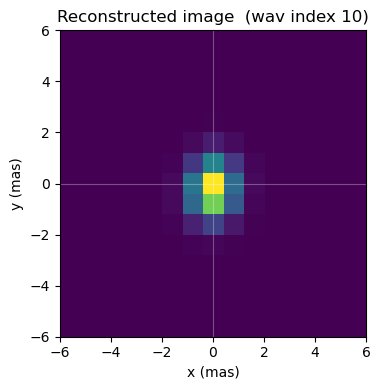

In [33]:
# Display the reconstructed image
im = locs2image(rc.post_locs, rc.axis_len).copy()
ext = (-IMAGE_FOV/2, IMAGE_FOV/2, -IMAGE_FOV/2, IMAGE_FOV/2)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(im, origin='upper', extent=ext)
ax.axvline(0, color='white', alpha=0.3, lw=0.8)
ax.axhline(0, color='white', alpha=0.3, lw=0.8)
ax.set_xlabel('x (mas)')
ax.set_ylabel('y (mas)')
wav_abs = int(fit_mm.wav_reconrange[wavind])
ax.set_title(f'Reconstructed image  (wav index {wav_abs})')
plt.tight_layout()
plt.show()

In [35]:
# ── Batch reconstruction across the signal window ───────────────────────────
# Adjust wavind_list to the range you care about.

wavind_list = np.arange(fitmin - wmin, fitmax - wmin)
images = {}

for wavind_i in wavind_list:
    wav_abs = int(fit_mm.wav_reconrange[wavind_i])
    print(f'Reconstructing wav {wav_abs} (specind {wavind_i}) ...')
    rc_i, _ = ru.run_reconstruction(
        fit_mm,
        wavind       = wavind_i,
        image_fov    = IMAGE_FOV,
        image_ngrid  = IMAGE_NGRID,
        n_trim       = 1,
        n_elements   = 50,
        target_chi2  = 1.0,
        burn_in_iter = 300,
        niter        = 800,
        plot         = False,
    )
    images[wav_abs] = locs2image(rc_i.post_locs, rc_i.axis_len).copy()

print('Done.')

Reconstructing wav 10 (specind 10) ...
loading model


225it [00:04, 45.87it/s]


all the fiber indices are used. saving the matrix to mat_full
preparing data for specind 10


100%|██████████| 800/800 [00:05<00:00, 159.38it/s]


Done
Final chi2 2.674161337549196
Reconstructing wav 11 (specind 11) ...
loading model


...

Done
Final chi2 3.8339200174520958
Reconstructing wav 19 (specind 19) ...
loading model


225it [00:04, 48.20it/s]


all the fiber indices are used. saving the matrix to mat_full
preparing data for specind 19


100%|██████████| 800/800 [00:05<00:00, 151.91it/s]

Done
Final chi2 3.1833069762481774
Done.


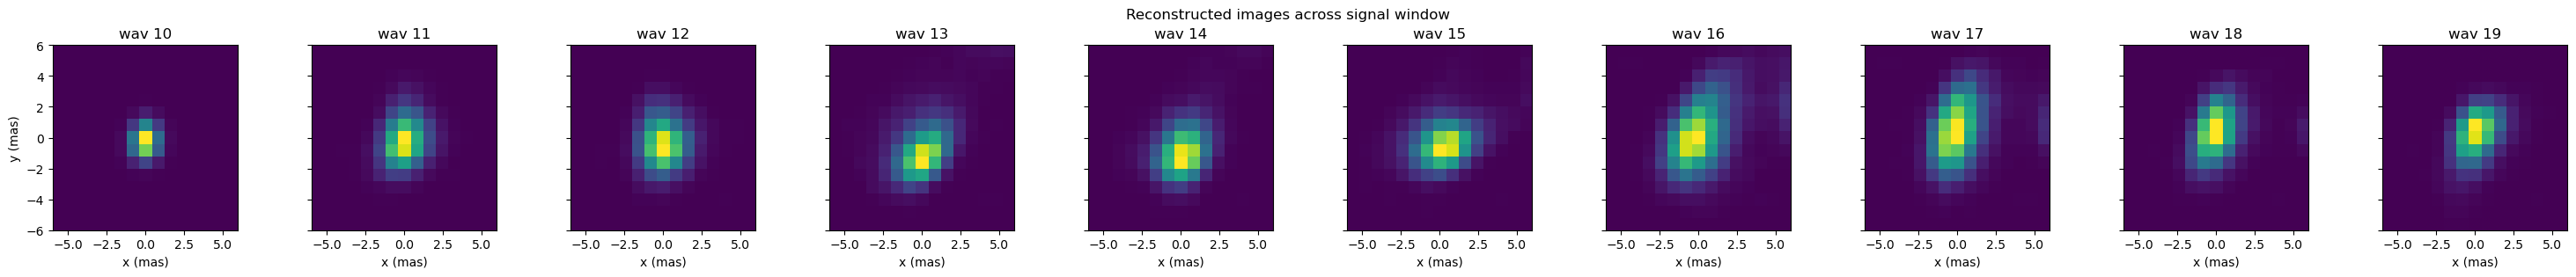

In [36]:
# Display all reconstructed images side by side
wavs = sorted(images)
n    = len(wavs)
fig, axs = plt.subplots(1, n, figsize=(n * 3, 3), sharex=True, sharey=True)
if n == 1:
    axs = [axs]
ext = (-IMAGE_FOV/2, IMAGE_FOV/2, -IMAGE_FOV/2, IMAGE_FOV/2)
for ax, w in zip(axs, wavs):
    ax.imshow(images[w], origin='upper', extent=ext)
    ax.set_title(f'wav {w}')
    ax.set_xlabel('x (mas)')
axs[0].set_ylabel('y (mas)')
fig.suptitle('Reconstructed images across signal window')
plt.tight_layout()
plt.show()